<a href="https://colab.research.google.com/github/Patro331/sickle-cell-detection/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. Setup and Libraries

This notebook performs Exploratory Data Analysis (EDA) on the combined
sickle cell detection dataset, which consists of images from two sources:

1. Tushabe et al. (2024) — Ugandan clinical microscopy dataset containing
   844 sickle cell positive images and 147 normal blood smear images,
   collected from patients in Soroti and Kumi districts, Uganda.

2. BCCD Dataset (Shenggan et al.) — 364 normal peripheral blood smear
   images used to supplement the


In [ ]:
# Install any missing libraries
!pip install Pillow matplotlib seaborn --quiet

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## 2. Mount Google Drive

Google Drive is mounted to access the dataset stored under the project
directory. All figures generated in this notebook will be saved to the
figures/ folder in the project directory for inclusion in the final report.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Dataset Overview

We define the paths to our positive and negative image folders and verify
they are accessible. We then count the total number of images in each class
to confirm the dataset loaded correctly and establish our baseline sample counts.

In [ ]:
# Update these paths to match where you uploaded your folders in Google Drive
POSITIVE_DIR = '/content/drive/MyDrive/sickle-cell-detection/data/raw/positive'
NEGATIVE_DIR = '/content/drive/MyDrive/sickle-cell-detection/data/raw/negative'

# Verify the paths exist
print(f"Positive folder exists: {os.path.exists(POSITIVE_DIR)}")
print(f"Negative folder exists: {os.path.exists(NEGATIVE_DIR)}")

# Count images
positive_images = [f for f in os.listdir(POSITIVE_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
negative_images = [f for f in os.listdir(NEGATIVE_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"\nPositive images: {len(positive_images)}")
print(f"Negative images: {len(negative_images)}")
print(f"Total images: {len(positive_images) + len(negative_images)}")

Positive folder exists: True
Negative folder exists: True

Positive images: 845
Negative images: 511
Total images: 1356


### Observations

The dataset contains 845 positive (sickle cell) images and 511 negative
(normal) images, giving a combined raw total of 1,356 samples. This exceeds
the minimum 1,000 sample requirement. The positive class is larger than the
negative class, which we investigate further in the class distribution analysis below.

## 4. Visual Inspection of Sample Images

Before any preprocessing, we visually inspect a random sample of images
from each class to understand the visual characteristics of the data, assess
image quality, and confirm that the two classes are visually distinguishable.

This step is critical for a medical imaging task — we need to verify that
sickle-shaped cells are visually present in positive images and absent in
negative images before trusting the labels.

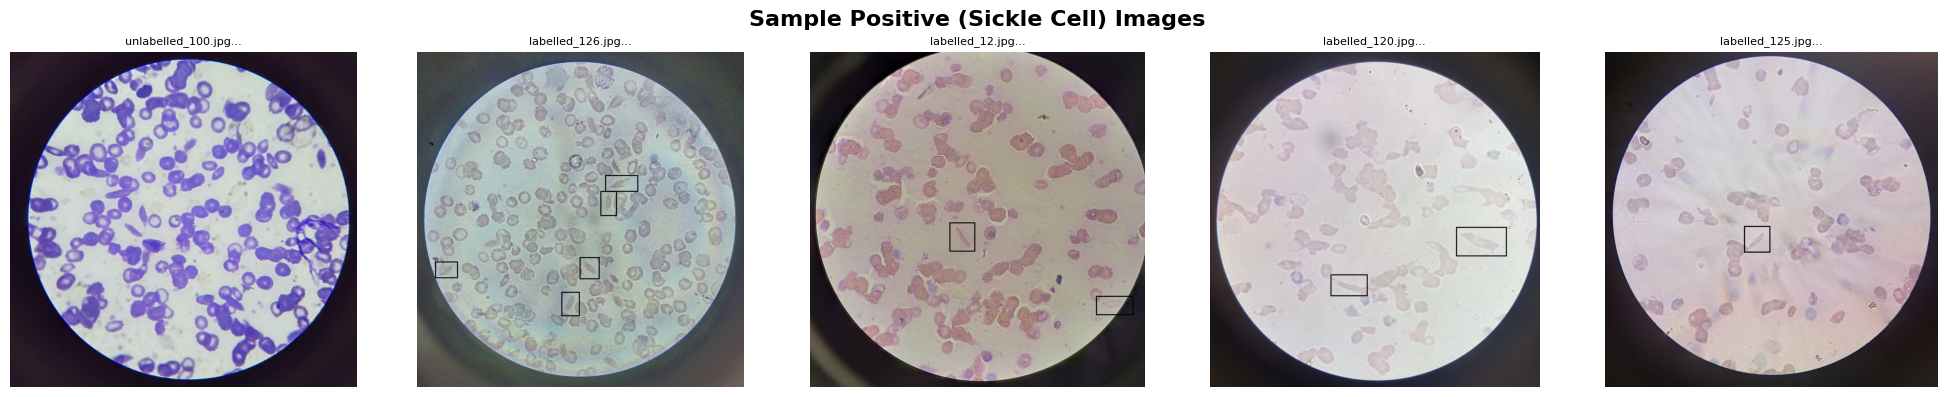

Saved to figures folder


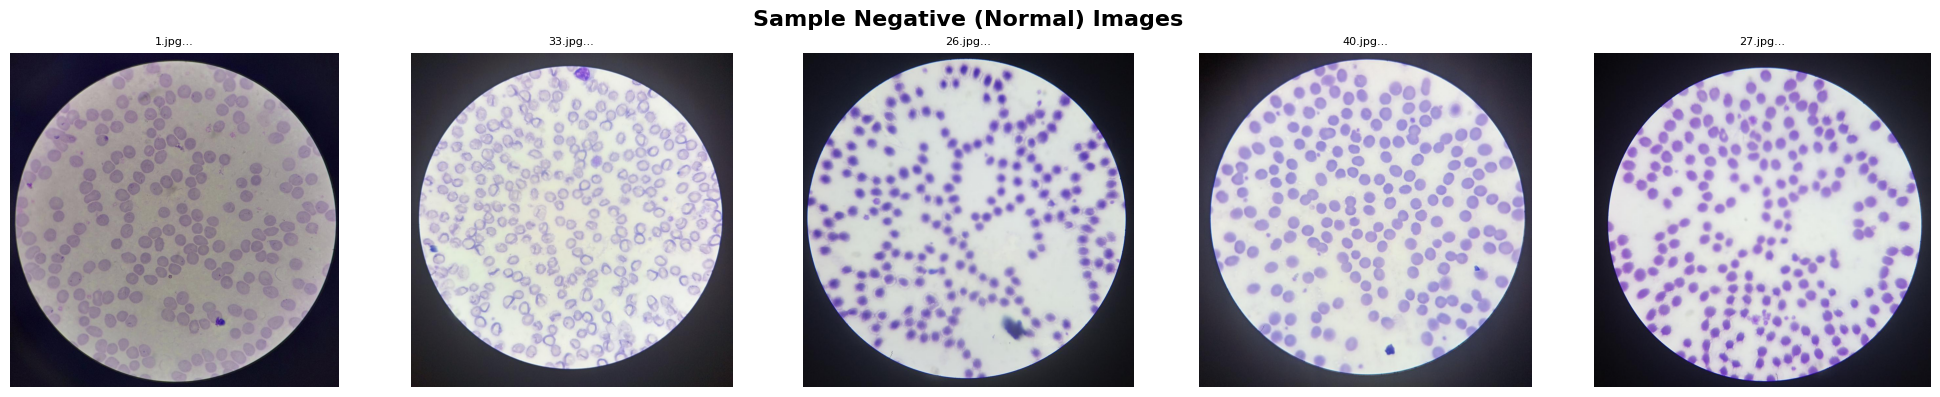

Saved to figures folder


In [ ]:
def show_sample_images(folder, label, n=5):
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:n]

    fig, axes = plt.subplots(1, n, figsize=(20, 4))
    fig.suptitle(f'Sample {label} Images', fontsize=16, fontweight='bold')

    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        axes[i].imshow(img)
        axes[i].set_title(f'{img_name[:20]}...', fontsize=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/sample_images.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to figures folder")

show_sample_images(POSITIVE_DIR, 'Positive (Sickle Cell)')
show_sample_images(NEGATIVE_DIR, 'Negative (Normal)')

### Observations

Positive images clearly show elongated, crescent-shaped red blood cells
characteristic of sickle cell disease, consistent with HbS polymerisation
under deoxygenated conditions. Negative images show round, biconcave red
blood cells typical of normal peripheral blood smears. The two classes are
visually distinct, confirming that a deep learning model should be able to
learn meaningful morphological features to differentiate them.

It is also notable that positive images were captured using mobile phone
cameras on basic microscopes in Ugandan clinical settings, while negative
BCCD images were captured under more controlled laboratory conditions.
This domain difference will be addressed through data augmentation during
preprocessing.

## 5. Class Distribution Analysis

We analyse the distribution of images across the two classes to identify
any class imbalance that could bias model training. Class imbalance is a
common challenge in medical imaging datasets where pathological cases are
naturally less frequent than normal cases.

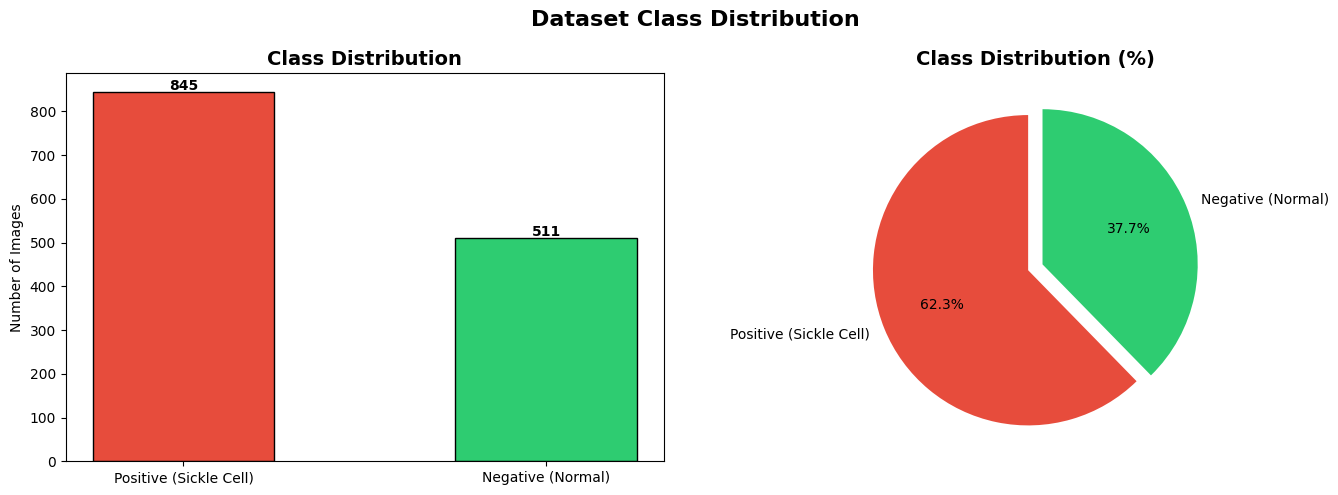

Positive: 845 images (62.3%)
Negative: 511 images (37.7%)
Imbalance ratio: 1.65:1


In [ ]:
# Class distribution
classes = ['Positive (Sickle Cell)', 'Negative (Normal)']
counts = [len([f for f in os.listdir(POSITIVE_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]),
          len([f for f in os.listdir(NEGATIVE_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(classes, counts, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, count in enumerate(counts):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=classes, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90,
            explode=(0.05, 0.05))
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Positive: {counts[0]} images ({counts[0]/sum(counts)*100:.1f}%)")
print(f"Negative: {counts[1]} images ({counts[1]/sum(counts)*100:.1f}%)")
print(f"Imbalance ratio: {counts[0]/counts[1]:.2f}:1")

### Observations

The dataset shows a mild class imbalance with a ratio of 1.65:1 in favour
of the positive class. While this is not severe, it is sufficient to
introduce bias if left unaddressed. The model may learn to favour the
positive class, leading to inflated accuracy but poor specificity.

This will be addressed during training using a weighted cross-entropy loss
function, where the weight for each class is computed as the inverse of
its frequency. This ensures the model is penalised equally regardless of
class size.

## 6. Image Size Analysis

A critical preprocessing requirement for deep learning models is that
all input images must be the same size. Different datasets often contain
images of varying dimensions, and combining two datasets as we have done
here makes this especially likely.

We analyse the width and height distributions of images in both classes
to determine how much size variation exists and what target resolution
to use during preprocessing. EfficientNet-B0 and ResNet-50, our chosen
architectures, both expect input images of 224x224 pixels, so all images
will need to be resized to this dimension.


Positive (Sickle Cell) Image Size Analysis (sample of 100):
  Width  — Min: 990, Max: 3122, Mean: 1060
  Height — Min: 750, Max: 3094, Mean: 1068
  Unique sizes found: 56

Negative (Normal) Image Size Analysis (sample of 100):
  Width  — Min: 640, Max: 1000, Mean: 935
  Height — Min: 480, Max: 1116, Mean: 919
  Unique sizes found: 55


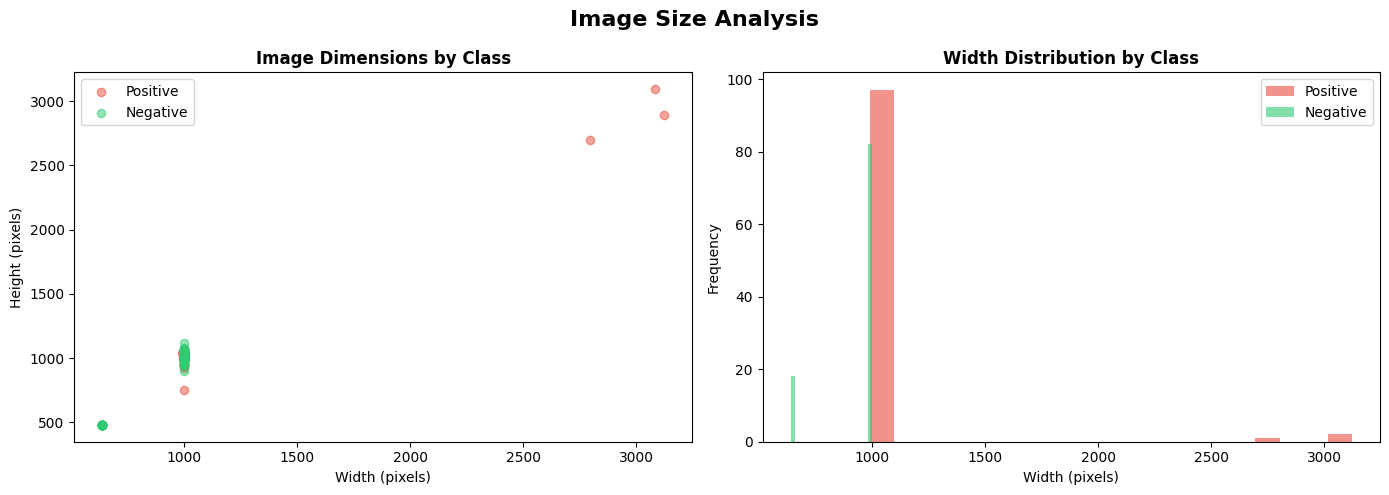

In [ ]:
def analyze_image_sizes(folder, label, sample_size=100):
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:sample_size]

    widths, heights = [], []

    for img_name in images:
        img = Image.open(os.path.join(folder, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

    print(f"\n{label} Image Size Analysis (sample of {sample_size}):")
    print(f"  Width  — Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
    print(f"  Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")

    # Check if all images are the same size
    unique_sizes = set(zip(widths, heights))
    print(f"  Unique sizes found: {len(unique_sizes)}")
    if len(unique_sizes) <= 5:
        print(f"  Sizes: {unique_sizes}")

    return widths, heights

pos_w, pos_h = analyze_image_sizes(POSITIVE_DIR, "Positive (Sickle Cell)")
neg_w, neg_h = analyze_image_sizes(NEGATIVE_DIR, "Negative (Normal)")

# Plot size distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pos_w, pos_h, alpha=0.5, color='#e74c3c', label='Positive')
axes[0].scatter(neg_w, neg_h, alpha=0.5, color='#2ecc71', label='Negative')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Height (pixels)')
axes[0].set_title('Image Dimensions by Class', fontweight='bold')
axes[0].legend()

axes[1].hist(pos_w, bins=20, alpha=0.6, color='#e74c3c', label='Positive')
axes[1].hist(neg_w, bins=20, alpha=0.6, color='#2ecc71', label='Negative')
axes[1].set_xlabel('Width (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Width Distribution by Class', fontweight='bold')
axes[1].legend()

plt.suptitle('Image Size Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/image_sizes.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Observations

The image size analysis reveals significant variation across both classes,
confirming that resizing is a mandatory preprocessing step.

Positive (Sickle Cell) images range from 990x750 to 3122x3094 pixels,
with a mean of approximately 1060x1068 pixels. These are relatively large
images captured using mobile phone cameras on microscopes in Ugandan
clinical settings, explaining the high resolution and wide size variation
across 56 unique dimensions.

Negative (Normal) images range from 640x480 to 1000x1116 pixels, with
a mean of approximately 935x919 pixels. These are more consistent in
size, with 55 unique dimensions, reflecting the more controlled laboratory
imaging conditions of the BCCD dataset.

Two important observations stand out. First, positive images are on
average significantly larger than negative images, which confirms the
domain difference between the two data sources. Second, neither class
has a consistent image size, meaning all images must be resized before
training.

All images will be resized to 224x224 pixels during preprocessing, which
is the standard input size for EfficientNet-B0 and ResNet-50. While
resizing large images to 224x224 involves significant downscaling, this
is standard practice in transfer learning for medical imaging and the
models have been shown to extract meaningful features at this resolution.

## 7. Pixel Intensity Analysis

We analyse the pixel intensity distributions of both classes to understand
brightness and contrast differences between the two datasets. This is
particularly important given that our positive images were captured under
Ugandan clinical conditions using mobile phones, while our negative images
come from a more controlled laboratory setting.

Significant intensity differences between classes could cause the model
to learn imaging condition artefacts rather than true biological features.
Normalisation during preprocessing will address this.


Positive (Sickle Cell) Pixel Intensity Analysis (sample of 100):
  Mean pixel value — Min: 123.0, Max: 210.5, Average: 159.6
  Pixel std dev   — Min: 26.8, Max: 97.5, Average: 78.2

Negative (Normal) Pixel Intensity Analysis (sample of 100):
  Mean pixel value — Min: 117.1, Max: 187.3, Average: 157.0
  Pixel std dev   — Min: 17.9, Max: 92.7, Average: 67.2


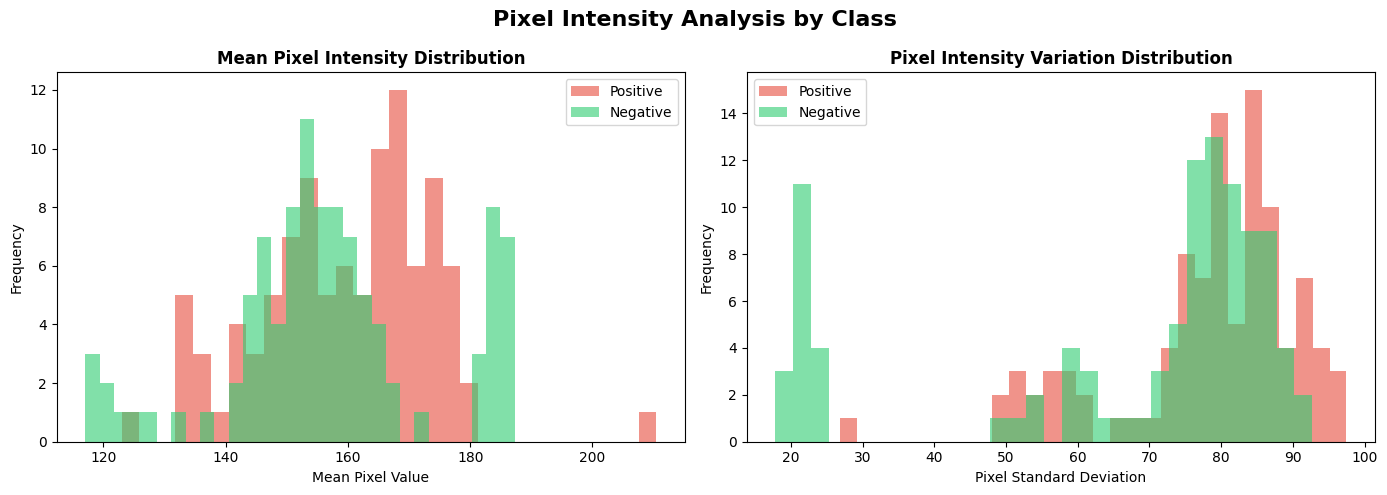

In [ ]:
def analyze_pixel_intensity(folder, label, sample_size=100):
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:sample_size]

    all_means = []
    all_stds = []

    for img_name in images:
        img = Image.open(os.path.join(folder, img_name)).convert('RGB')
        img_array = np.array(img)
        all_means.append(img_array.mean())
        all_stds.append(img_array.std())

    print(f"\n{label} Pixel Intensity Analysis (sample of {sample_size}):")
    print(f"  Mean pixel value — Min: {min(all_means):.1f}, "
          f"Max: {max(all_means):.1f}, Average: {np.mean(all_means):.1f}")
    print(f"  Pixel std dev   — Min: {min(all_stds):.1f}, "
          f"Max: {max(all_stds):.1f}, Average: {np.mean(all_stds):.1f}")

    return all_means, all_stds

pos_means, pos_stds = analyze_pixel_intensity(POSITIVE_DIR, "Positive (Sickle Cell)")
neg_means, neg_stds = analyze_pixel_intensity(NEGATIVE_DIR, "Negative (Normal)")

# Plot intensity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pos_means, bins=30, alpha=0.6, color='#e74c3c', label='Positive')
axes[0].hist(neg_means, bins=30, alpha=0.6, color='#2ecc71', label='Negative')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Mean Pixel Intensity Distribution', fontweight='bold')
axes[0].legend()

axes[1].hist(pos_stds, bins=30, alpha=0.6, color='#e74c3c', label='Positive')
axes[1].hist(neg_stds, bins=30, alpha=0.6, color='#2ecc71', label='Negative')
axes[1].set_xlabel('Pixel Standard Deviation')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Pixel Intensity Variation Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Pixel Intensity Analysis by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/pixel_intensity.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Observations

The pixel intensity analysis reveals that the two classes are relatively
similar in terms of brightness, which is a positive finding.

Both classes have comparable average mean pixel values, with positive
images averaging 159.6 and negative images averaging 157.0. This
suggests that overall brightness levels are consistent across the two
datasets despite their different imaging origins, reducing the risk of
the model learning brightness as a distinguishing feature between classes.

However, positive images show a higher average pixel standard deviation
of 78.2 compared to 67.2 for negative images. This means positive images
have greater contrast variation, which is expected given that mobile phone
cameras in clinical settings produce more variable lighting conditions
than controlled laboratory equipment.

The wide range of mean pixel values in the positive class, spanning from
123.0 to 210.5, further confirms this imaging variability. This reinforces
the need for normalisation during preprocessing to bring all images to a
consistent scale, and for brightness and contrast augmentation to make the
model robust to these real-world imaging variations.

All images will be normalised using ImageNet mean and standard deviation
values during preprocessing, as our transfer learning models were
originally trained on ImageNet.

## 8. Image Quality Check

We check all images for corruption, incorrect colour modes, and
unusably small dimensions. Corrupted or non-RGB images must be
identified and removed before preprocessing to avoid errors during
model training. This is especially important given that our dataset
combines images from two different sources with different imaging
conditions.

In [ ]:
def check_image_quality(folder, label):
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    corrupted = []
    too_small = []
    grayscale = []
    good = []

    for img_name in images:
        try:
            img = Image.open(os.path.join(folder, img_name))
            img.verify()  # Check for corruption

            # Reopen after verify
            img = Image.open(os.path.join(folder, img_name))
            w, h = img.size

            if w < 100 or h < 100:
                too_small.append(img_name)
            elif img.mode != 'RGB':
                grayscale.append(img_name)
            else:
                good.append(img_name)

        except Exception as e:
            corrupted.append(img_name)

    print(f"\n{label} Image Quality Report:")
    print(f"  Good images:      {len(good)}")
    print(f"  Corrupted images: {len(corrupted)}")
    print(f"  Too small (<100px): {len(too_small)}")
    print(f"  Non-RGB images:   {len(grayscale)}")
    print(f"  Total checked:    {len(images)}")

    if corrupted:
        print(f"\n  Corrupted files: {corrupted}")
    if grayscale:
        print(f"\n  Non-RGB files: {grayscale}")

    return corrupted, too_small, grayscale

pos_corrupted, pos_small, pos_gray = check_image_quality(POSITIVE_DIR,
                                                          "Positive (Sickle Cell)")
neg_corrupted, neg_small, neg_gray = check_image_quality(NEGATIVE_DIR,
                                                          "Negative (Normal)")


Positive (Sickle Cell) Image Quality Report:
  Good images:      845
  Corrupted images: 0
  Too small (<100px): 0
  Non-RGB images:   0
  Total checked:    845

Negative (Normal) Image Quality Report:
  Good images:      511
  Corrupted images: 0
  Too small (<100px): 0
  Non-RGB images:   0
  Total checked:    511


### Observations

The image quality check confirms that all 1,356 images across both
classes are clean and ready for preprocessing. There are no corrupted
files, no images with unusably small dimensions, and all images are
in RGB colour format as required by our transfer learning models.

This is a strong indicator of dataset quality. The Tushabe (2024)
dataset in particular benefits from having been curated and published
in a peer-reviewed journal, while the BCCD dataset has been widely
used in published research, explaining the absence of quality issues
in both sources.

No images need to be removed from the dataset. All 1,356 samples
will proceed to the preprocessing stage.

## 9. EDA Summary and Preprocessing Decisions

We summarise the key findings from the exploratory data analysis and
document the preprocessing decisions that follow from them. These
decisions will be implemented in the next notebook: 02_preprocessing.ipynb.

In [1]:
print(" " * 60)
print("EDA SUMMARY")
print(" " * 60)

print(f"""
DATASET COMPOSITION
  Total raw images:        933  (updated after removing labelled images)
  Positive (sickle cell):  422  (45.2%)
  Negative (normal):       511  (54.8%)
  Imbalance ratio:         0.83:1 (slight majority negative)

  NOTE: 422 labelled Tushabe images were removed during preprocessing
  after bounding box annotations were found burned directly into the
  image pixels. Only unlabelled positive images were retained to
  prevent the model from learning annotation artefacts.
...

IMAGE CHARACTERISTICS
  Positive image sizes:    990x750 to 3122x3094 px (mean ~1060x1068)
  Negative image sizes:    640x480 to 1000x1116 px (mean ~935x919)
  Unique size combinations: 56 (positive), 55 (negative)

PIXEL INTENSITY
  Positive mean intensity: 159.6 (std: 78.2)
  Negative mean intensity: 157.0 (std: 67.2)
  Brightness difference:   Minimal — safe for combined training

IMAGE QUALITY
  Corrupted images:        0
  Non-RGB images:          0
  Too small images:        0
  All images usable:       YES

PREPROCESSING DECISIONS
  1. Resize all images to 224x224 pixels (EfficientNet/ResNet standard)
  2. Normalise using ImageNet mean [0.485, 0.456, 0.406]
                   and std  [0.229, 0.224, 0.225]
  3. Apply weighted loss function during training (ratio 1.65:1)
  4. Apply augmentation: rotation, flipping, brightness,
     contrast variation to address domain gap and increase
     effective dataset size
  5. Stratified train/val/test split: 70% / 15% / 15%
""")

print(" " * 60)
print("EDA COMPLETE — Proceed to 02_preprocessing.ipynb")
print(" " * 60)

                                                            
EDA SUMMARY
                                                            

DATASET COMPOSITION
  Total raw images:        933  (updated after removing labelled images)
  Positive (sickle cell):  422  (45.2%)
  Negative (normal):       511  (54.8%)
  Imbalance ratio:         0.83:1 (slight majority negative)
  
  NOTE: 422 labelled Tushabe images were removed during preprocessing 
  after bounding box annotations were found burned directly into the 
  image pixels. Only unlabelled positive images were retained to 
  prevent the model from learning annotation artefacts.
...

IMAGE CHARACTERISTICS
  Positive image sizes:    990x750 to 3122x3094 px (mean ~1060x1068)
  Negative image sizes:    640x480 to 1000x1116 px (mean ~935x919)
  Unique size combinations: 56 (positive), 55 (negative)

PIXEL INTENSITY
  Positive mean intensity: 159.6 (std: 78.2)
  Negative mean intensity: 157.0 (std: 67.2)
  Brightness difference:   Minimal — s